<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cement        10000 non-null  float64
 1   water         10000 non-null  float64
 2   curing_time   10000 non-null  float64
 3   quality_pass  10000 non-null  int64  
dtypes: float64(3), int64(1)
memory usage: 312.6 KB

--- Summary Statistics ---
             cement         water   curing_time  quality_pass
count  10000.000000  10000.000000  10000.000000  10000.000000
mean     299.401116    125.595515     15.462304      0.316100
std      114.825751     43.058332      8.366611      0.464976
min      100.012459     50.007013      1.000624      0.000000
25%      200.536408     88.358690      8.104067      0.000000
50%      298.847243    126.341123     15.591436      0.000000
75%      397.004436    162.662388     22.607941      1.000000
max      499.994776    199.977116     29.995824      1.0000

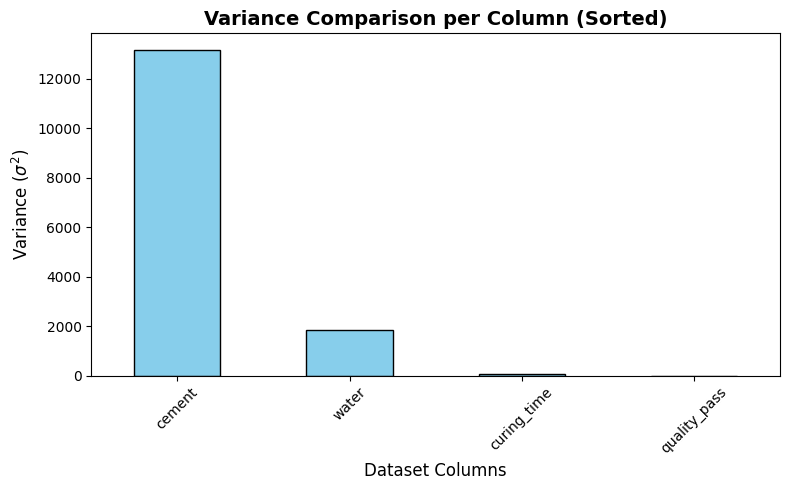

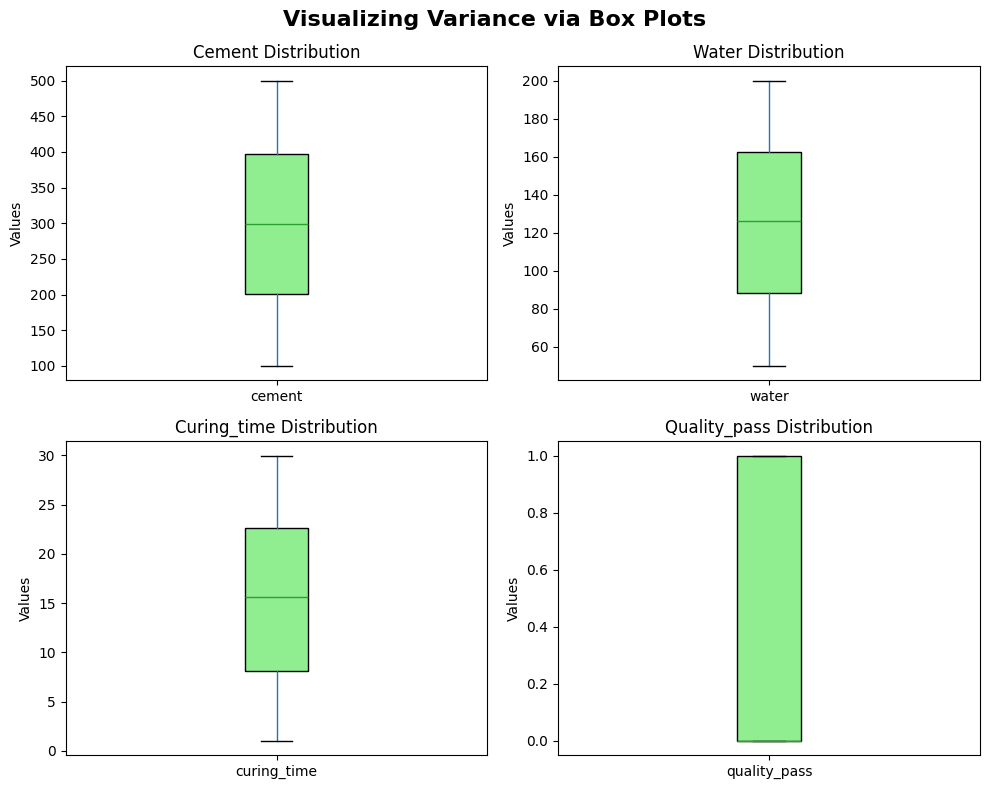

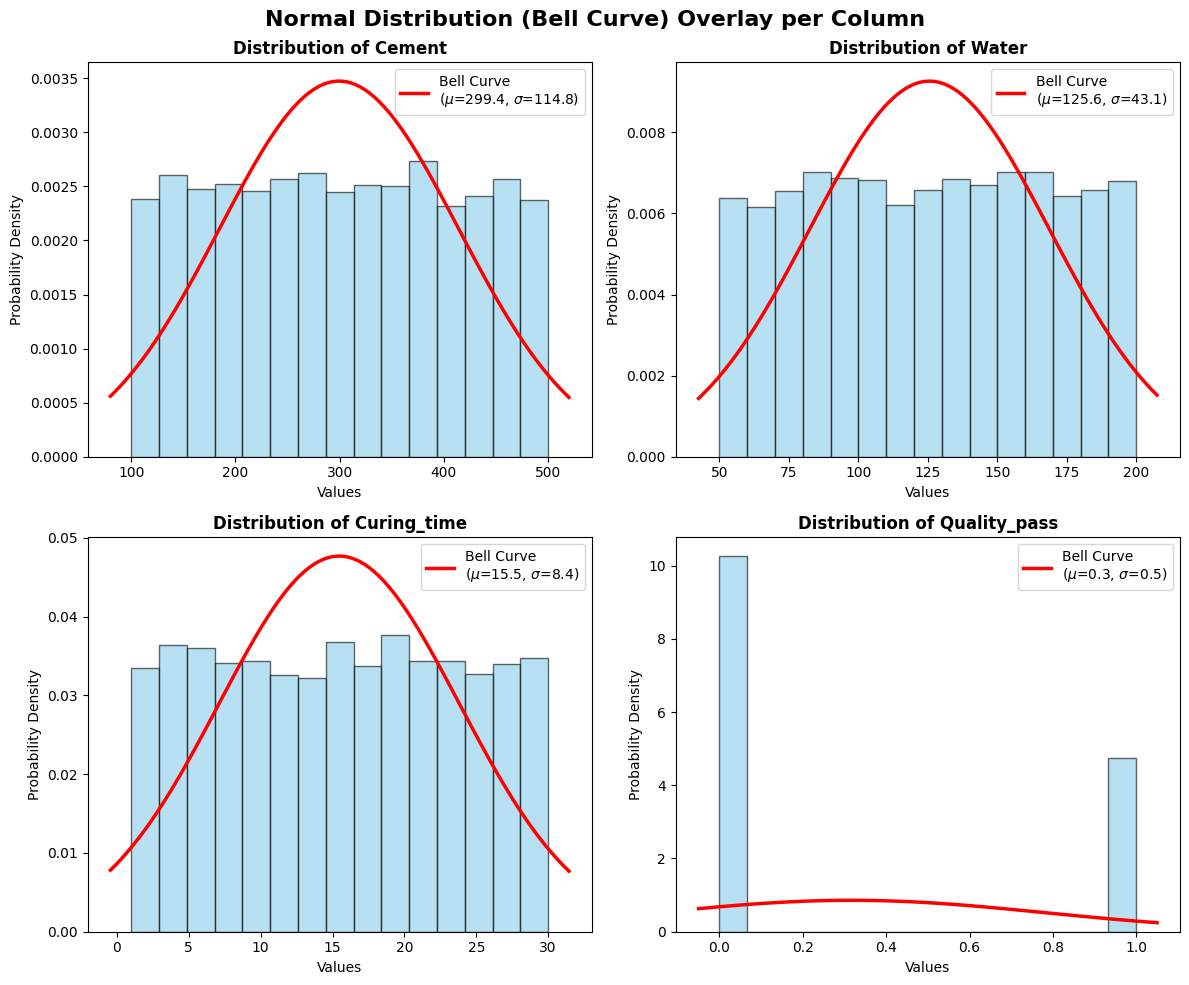

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from scipy.stats import norm

df = pd.read_csv('civil.csv')
df.info()
print("\n--- Summary Statistics ---")
print(df.describe())

# cement	water	curing_time	quality_pass - business problem is to predict quality_pass


print("\n--- Target Variable ('quality_pass') Distribution ---")
print(df['quality_pass'].value_counts())

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

df.drop_duplicates(inplace=True)


# 2. Calculate the variance for each column and sort them
# Sorting ensures the bar chart is easy to read
variances = df.var().sort_values(ascending=False)
print("Calculated Variances:\n", variances)

# 3. PLOT 1: Bar Chart of Raw Variance Values
fig1, ax1 = plt.subplots(figsize=(8, 5))
variances.plot(kind='bar', ax=ax1, color='skyblue', edgecolor='black')

ax1.set_title('Variance Comparison per Column (Sorted)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Variance ($\sigma^2$)', fontsize=12)
ax1.set_xlabel('Dataset Columns', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('variance_bar_chart.png')  # Saves the bar chart


# 4. PLOT 2: Box Plots to Visually See the Spread (Variance)
# Since scales differ wildly, subplots keep the distributions readable
fig2, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()  # Flatten the 2x2 grid to easily loop through it

for i, column in enumerate(df.columns):
    df.boxplot(column=[column], ax=axes[i], grid=False, 
               patch_artist=True, boxprops=dict(facecolor='lightgreen'))
    axes[i].set_title(f'{column.capitalize()} Distribution', fontsize=12)
    axes[i].set_ylabel('Values')

fig2.suptitle('Visualizing Variance via Box Plots', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('variance_box_plots.png')  # Saves the box plots

# 2. Set up a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()  # Flatten the 2x2 grid into a 1D array to loop easily

# 3. Loop through each column and plot the bell curve
for i, col in enumerate(df.columns):
    # Plot a density histogram of the actual data
    # 'density=True' scales the y-axis so the total area under the histogram equals 1
    axes[i].hist(df[col], bins=15, density=True, alpha=0.6, color='skyblue', edgecolor='black')
    
    # Calculate the mean (mu) and standard deviation (std) to fit the bell curve
    mu, std = norm.fit(df[col])
    
    # Create an array of x-values ranging across the width of the plot
    xmin, xmax = axes[i].get_xlim()
    x = np.linspace(xmin, xmax, 100)
    
    # Calculate the normal probability density function (the bell curve line)
    p = norm.pdf(x, mu, std)
    
    # Plot the bell curve line
    axes[i].plot(x, p, color='red', linewidth=2.5, 
                 label=f'Bell Curve\n($\mu$={mu:.1f}, $\sigma$={std:.1f})')
    
    # Style the individual subplots
    axes[i].set_title(f'Distribution of {col.capitalize()}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Values')
    axes[i].set_ylabel('Probability Density')
    axes[i].legend(loc='upper right')

# 4. Style the overall figure layout and save
fig.suptitle('Normal Distribution (Bell Curve) Overlay per Column', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('guassian.png')  # Saves the visualization as an image


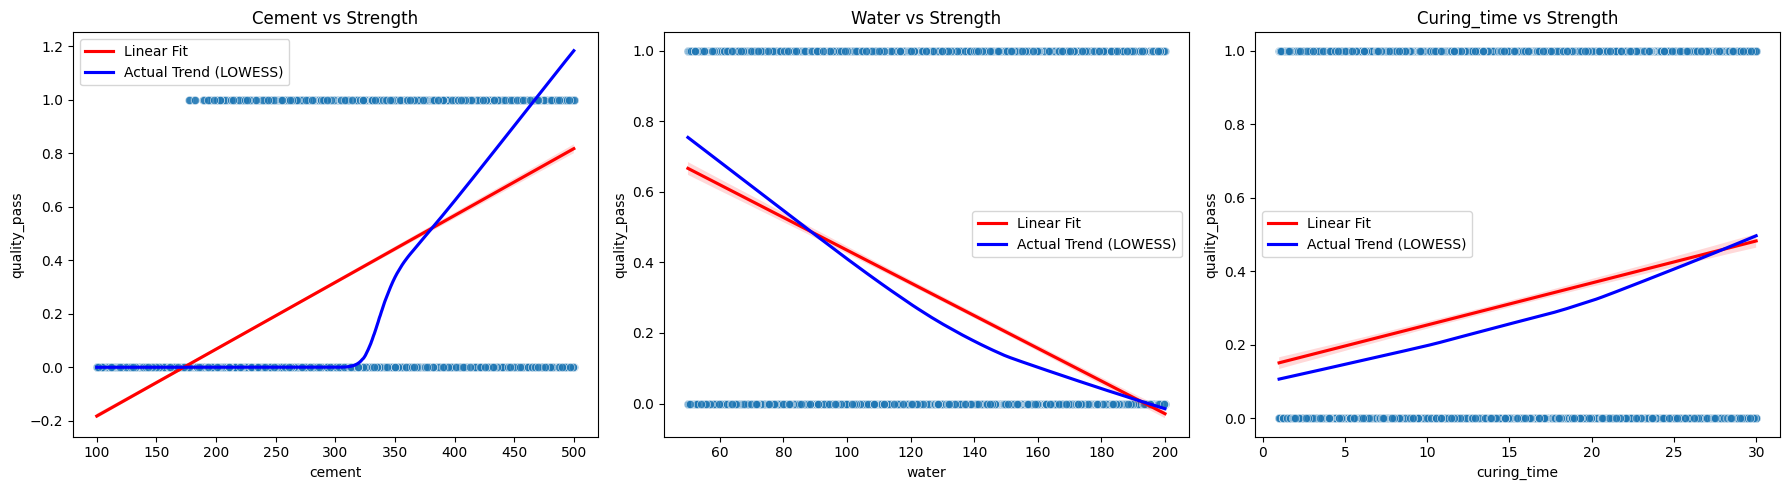

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Plot scatter plots with a linear fit vs a smoothed non-linear fit (lowess)
features = ['cement', 'water', 'curing_time']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(features):
    # Plot the data points
    sns.scatterplot(data=df, x=col, y='quality_pass', ax=axes[i], alpha=0.7)
    
    # Draw a straight linear regression line (Red)
    sns.regplot(data=df, x=col, y='quality_pass', ax=axes[i], scatter=False, color='red', label='Linear Fit')
    
    # Draw a flexible non-linear curve (Blue) to see if it bends
    sns.regplot(data=df, x=col, y='quality_pass', ax=axes[i], scatter=False, color='blue', lowess=True, label='Actual Trend (LOWESS)')
    
    axes[i].set_title(f'{col.capitalize()} vs Strength')
    axes[i].legend()

plt.tight_layout()
plt.show()

#If the red line (linear) and the blue line (actual trend) lie perfectly on top of each other, the relationship is linear. If the blue line noticeably curves or waves away from the straight red line, it is non-linear - here it is linear

In [16]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import mean_absolute_percentage_error


#Cap outliers
for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Cap values instead of dropping rows to preserve dataset size
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

X = df.drop(columns=['quality_pass'], axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Set your new categorical column as the target
y = df['quality_pass']


print(X.head())
print(y.head())

print(X.size)
print(y.size)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

       cement       water  curing_time
0  493.335332  194.595960    15.283600
1  358.906293  146.974795    23.631829
2  178.709963  141.561395    23.897515
3  458.443942  167.254985    27.576498
4  124.381876  129.153569     1.555740
0    0
1    0
2    0
3    1
4    0
Name: quality_pass, dtype: int64
30000
10000


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import log_loss

# Create and train the Logistic Regression model
logistic_model = LogisticRegression()
logistic_model.fit(X_train, y_train)

# Predict on test data
y_pred = logistic_model.predict(X_test)

# Evaluate the model
print("\nLogistic Regression:")
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Predict probabilities (not just labels)
y_pred_prob = logistic_model.predict_proba(X_test)
# print('log loss',y_pred_prob)
print(f"Log Loss: {log_loss(y_test, y_pred_prob)}")

# accuracy is 0.997, there are no true negatives and 6 false positives. The model's f1 score is 1 and may be over fitted



Logistic Regression:
Accuracy: 0.997
Confusion Matrix:
[[1390    0]
 [   6  604]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1390
           1       1.00      0.99      1.00       610

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

Log Loss: 0.03719911621483617
